This script calculates the % of films within each of the film genres that feature specific album genres and generates the heatmap to visualiz the matching strength\. 


In [1]:
# Standard library imports
import os

# Third-party imports
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Load the data
df = pd.read_csv('/work/pipeline/3.5.Wide_exploded_genre.csv')


/tmp/ipykernel_601/2998985317.py:2: DtypeWarning: Columns (45,49,58,84) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/work/pipeline/3.5.Wide_exploded_genre.csv')


In [3]:
# 2. Map raw column names to clean display labels
album_genre_map = {
    'album_ambient_experimental': 'Ambient Experimental',
    'album_classical_orchestral': 'Classical Orchestral',
    'album_electronic': 'Electronic',
    'album_hip_hop_rnb': 'Hip Hop/RnB',
    'album_pop': 'Pop',
    'album_rock': 'Rock',
    'album_world_folk': 'World/Folk'
}
album_genre_cols = list(album_genre_map.keys())

In [4]:
# 3. Extract and expand Film Genres (since one film can have multiple)
df['film_genres'] = df['film_genres'].fillna('')
unique_film_genres = sorted(list(set([g.strip() for entries in df['film_genres'] for g in entries.split(',') if g])))

In [5]:
# Calculate the "Match Up" Statistics
# We create a matrix showing: What % of [Film Genre] movies have [Album Genre] soundtracks?
stats_matrix = pd.DataFrame(index=unique_film_genres, columns=album_genre_cols)

for f_genre in unique_film_genres:
    # Filter rows containing this specific film genre
    subset = df[df['film_genres'].str.contains(f_genre)]
    total_count = len(subset)
    
    if total_count > 0:
        for a_genre in album_genre_cols:
            # Count how many of these films have the specific album genre marked as True/1
            matches = subset[a_genre].fillna(0).astype(bool).sum()
            stats_matrix.loc[f_genre, a_genre] = (matches / total_count) * 100
    else:
        stats_matrix.loc[f_genre, :] = 0

In [6]:
# RENAME the columns for a cleaner chart
stats_matrix = stats_matrix.rename(columns=album_genre_map).astype(float)

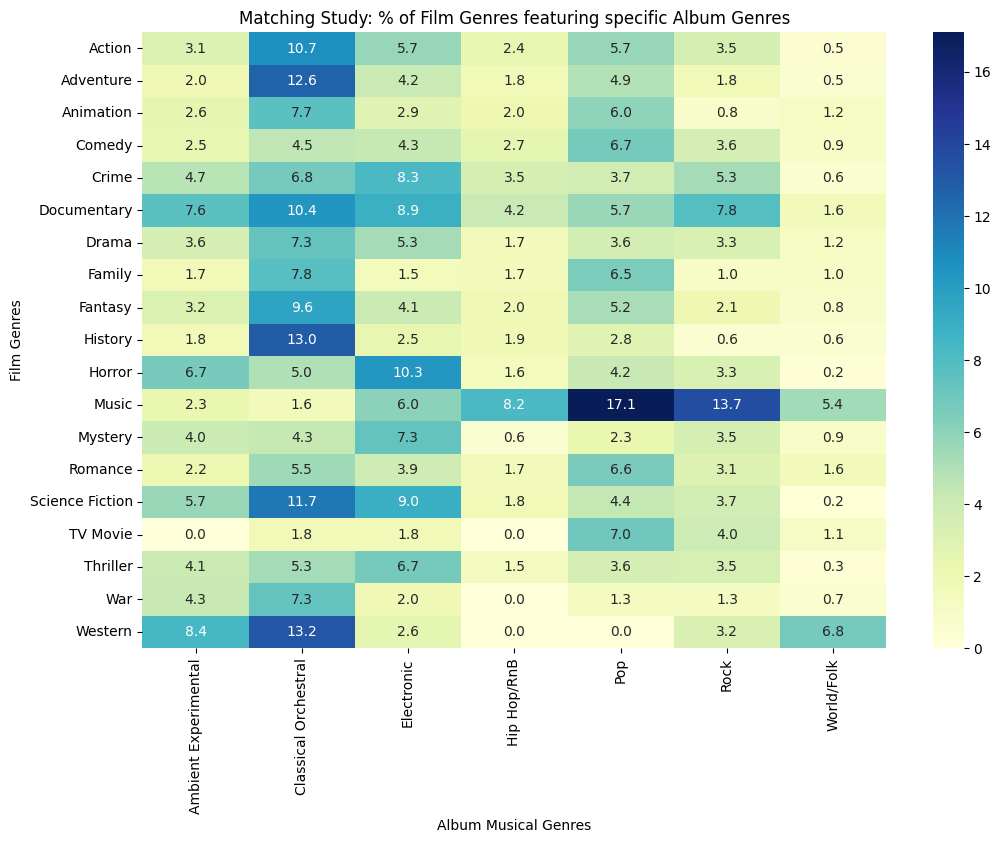

In [7]:
# Visualize the results
plt.figure(figsize=(12, 8))
sns.heatmap(stats_matrix.astype(float), annot=True, cmap='YlGnBu', fmt='.1f')
plt.title('Matching Study: % of Film Genres featuring specific Album Genres')
plt.xlabel('Album Musical Genres')
plt.ylabel('Film Genres')
plt.savefig('genre_matching_study.png')

# Save the stats to a CSV for further inspection
# stats_matrix.to_csv('film_album_genre_correlation.csv')

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=b124131d-2024-4253-bb46-8043aed4b78f' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>